In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv('fruit_classification_dataset.csv')

In [4]:
df.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana


In [5]:
df.isnull().sum()

size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64

In [6]:
cat_cols = ["color", "taste","shape"]
for i in cat_cols:
    print(df[i].value_counts())

color
green     2029
red       1943
brown     1541
yellow    1002
pink       998
orange     996
purple     988
blue       503
Name: count, dtype: int64
taste
sweet    7504
tangy    2015
sour      481
Name: count, dtype: int64
shape
round    5016
oval     4482
long      502
Name: count, dtype: int64


In [ ]:
encoded_df = pd.get_dummies(df, columns=cat_cols)  # Each category becomes a separate column
encoded_df.head()

,size (cm),weight (g),avg_price (₹),fruit_name,color_blue,color_brown,color_green,color_orange,color_pink,color_purple,color_red,color_yellow,taste_sour,taste_sweet,taste_tangy,shape_long,shape_oval,shape_round
0,25.4,3089.2,137.1,watermelon,False,False,True,False,False,False,False,False,False,True,False,False,False,True
1,24.6,3283.9,163.8,watermelon,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,7.8,319.0,91.3,custard apple,False,False,True,False,False,False,False,False,False,True,False,False,False,True
3,20.0,1607.0,85.7,papaya,False,False,False,True,False,False,False,False,False,True,False,False,True,False
4,10.2,131.5,37.8,banana,False,False,False,False,False,False,False,True,False,True,False,True,False,False


In [ ]:
x = encoded_df.drop(columns="fruit_name",axis = 1)
y = encoded_df["fruit_name"]

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=4,
    oob_score=True,
    max_features=10
    )
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true

In [12]:
pred_y = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_y))

Accuracy: 1.0


Text(0.5, 23.52222222222222, 'Predicted')

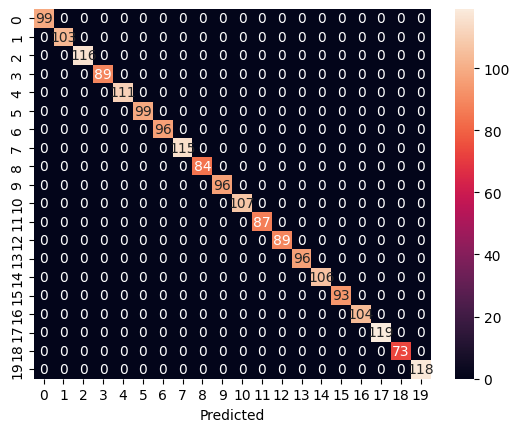

In [24]:
cm = confusion_matrix(y_test, pred_y)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')

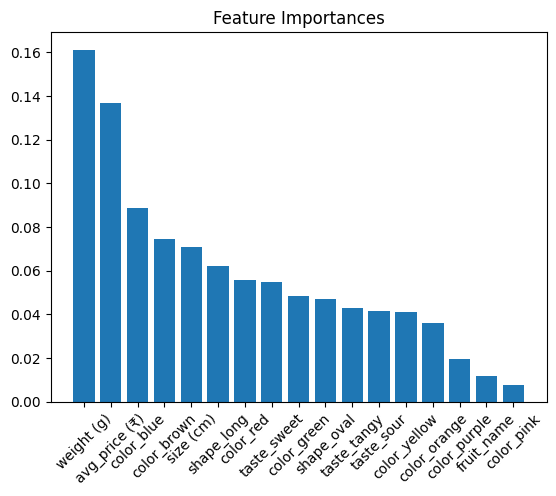

In [22]:
imp = rf.feature_importances_
index = np.argsort(imp)[::-1]

plt.figure()
plt.title("Feature Importances")
plt.bar(range(len(imp)), imp[index])
plt.xticks(range(len(imp)), [encoded_df.columns[i] for i in index], rotation=45)
plt.show()